In [256]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from scipy.stats import kurtosis, skew
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import zscore
from sklearn.preprocessing import Imputer

In [257]:
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc

In [258]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
from sklearn.metrics import roc_curve, auc

Campaign for selling personal loans.

This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are liability customers (depositors) with varying size of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio with minimal budget.

The department wants to build a model that will help them identify the potential customers who have higher probability of purchasing the loan. This will increase the success ratio while at the same time reduce the cost of the campaign.

The file Bank_Personal_Loan_Modelling.csvView in a new window  contains data on 5000 customers. The data include customer demographic information (age, income, etc.), the customer's relationship with the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (Personal Loan). Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that was offered to them in the earlier campaign.

### Q1) Read the column description and ensure you understand each attribute well :

#### Ans)
#### Below are the column descriptions as per my understanding :

ID : Serial Number of the number of customers.    
Age : Age of Customers.  
Experience : Number of years the customer has been dealing with the Bank.  
Income : Income of the Customers (in 1000 dollars yearly).   
ZIP Code : Postal Code of the address.      
Family : Number of Members in the Family.     
CCAvg : On an Average the Credit Card Bill of the Customer.   
Education : Categorical Variable defining Level of Education of customer 3 being highly educated.      
Mortgage : Mortgage Loan Amount taken by the Customers (in 1000 dollars).  
Securities Account : Categorical Variable specifying if Customer has a Securities Account or Not.   
CD Account : Categorical Variable specifying if Customer has a Checking Account or Not.  
Online : Categorical Variable specifying if Customer has opted for Online Banking or Not.  
CreditCard : Categorical Variable specifying if Customer has a Credit Card or Not.
##### Personal Loan : Categorical Variable specifying if Customer has taken Personal Loan or Not.  <-- This is the Target Variable


### Q2) Study the data distribution in each attribute, share your findings. (5 points)

#### Ans)

In [259]:
#Load the file from local directory using pd.read_csv which is a special form of read_table
bank = pd.read_csv("Bank_Personal_Loan_Modelling-1.csv")

In [260]:
bank.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [261]:
# Analysis of the distribution of the various attributes
bank.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


"Experience" column has wrong inputs so replacing negative values with 0.

In [262]:
bank.replace(-1,0, inplace=True)
bank.replace(-2,0, inplace=True)
bank.replace(-3,0, inplace=True)

Normal Distribution Properties are :   
1) Mean = Median.   
2) The Normal Distribution is symmetrical.    
3) IQR = 1.33 SD.      
4) Range = 6 SD.     
5) Kurtosis & Skewness is 0.    

## Distribution of all Numerical attributes :   


### 1) Experience

In [263]:
bank["Experience"].describe()

count    5000.000000
mean       20.119600
std        11.440484
min         0.000000
25%        10.000000
50%        20.000000
75%        30.000000
max        43.000000
Name: Experience, dtype: float64

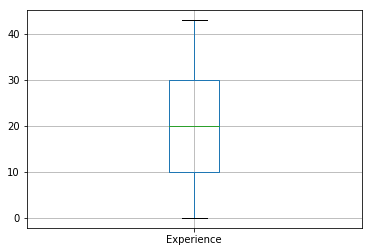

In [264]:
bank.boxplot(column='Experience')

In [265]:
print("Standard Deviation of Experience Column is : " , np.std(bank["Experience"], axis=0))
print("IQR of Experience Column is : " , 30-10)
print("Range of Experience Column is : " , 43-0)
print("Kurtosis of Experience Column is : " , kurtosis(bank["Experience"]))
print("Skewness of Experience Column is : " , skew(bank["Experience"]))  

Standard Deviation of Experience Column is :  11.439339834098845
IQR of Experience Column is :  20
Range of Experience Column is :  43
Kurtosis of Experience Column is :  -1.1357944471400356
Skewness of Experience Column is :  -0.017215538722506932


With the above we understand that :   
1) Mean (20.11) is approximately same as Median (20).   
2) Box Plot is slightly skewed.   
3) The Inter Quartile Range is 1.75 times Standard Deviation.   
4) Range = 3.75 times Standard Deviation.    
5) Kurtosis = -1.14 & Skewness is -0.02.    

So we conclude that :    
The Experiance is slightly skewed.   
Range is lower than what is expected in Normal Distribution, this is perfectly fine.     
Skewness is slightly negative and Kurtosis is also negative indicating that the distribution is less peaked than a normal distribution.

### 2) Income

In [266]:
bank["Income"].describe()

count    5000.000000
mean       73.774200
std        46.033729
min         8.000000
25%        39.000000
50%        64.000000
75%        98.000000
max       224.000000
Name: Income, dtype: float64

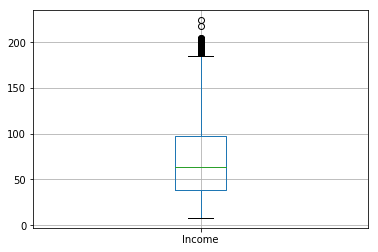

In [267]:
bank.boxplot(column='Income')

In [268]:
print("Standard Deviation of Income Column is : " , np.std(bank["Income"], axis=0))
print("IQR of Income Column is : " , 30-10)
print("Range of Income Column is : " , 43-0)
print("Kurtosis of Income Column is : " , kurtosis(bank["Income"]))
print("Skewness of Income Column is : " , skew(bank["Income"]))

Standard Deviation of Income Column is :  46.02912571796256
IQR of Income Column is :  20
Range of Income Column is :  43
Kurtosis of Income Column is :  -0.045399717980349585
Skewness of Income Column is :  0.8410861846424931


With the above we understand that :   
1) Mean (20.11) is approximately same as Median (20).   
2) Box Plot is slightly skewed.   
3) The Inter Quartile Range is 1.75 times Standard Deviation.   
4) Range = 3.75 times Standard Deviation.    
5) Kurtosis = -1.14 & Skewness is -0.02.   

So we conclude that :    
The Experiance is slightly skewed.   
Range is lower than what is expected in Normal Distribution, this is perfectly fine.     
Skewness is slightly negative and Kurtosis is also negative indicating that the distribution is less peaked than a normal distribution.

#### Hence removing all the columns having Income > 200, since they are outliers.

In [288]:
# Get names of indexes for which column Income > 200
indexNames = bank[ bank['Income'] > 200 ].index

In [291]:
# Delete these row indexes from dataFrame
bank.drop(indexNames, inplace=True)

### 3) CCAvg

In [269]:
bank["CCAvg"].describe()

count    5000.000000
mean        1.937938
std         1.747659
min         0.000000
25%         0.700000
50%         1.500000
75%         2.500000
max        10.000000
Name: CCAvg, dtype: float64

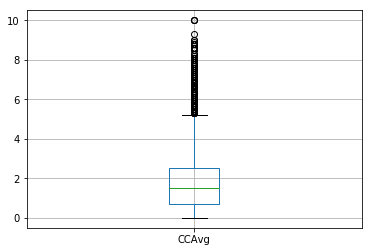

In [270]:
bank.boxplot(column='CCAvg')

In [271]:
print("Standard Deviation of CCAvg Column is : " , np.std(bank["CCAvg"], axis=0))
print("IQR of CCAvg Column is : " , 2.5-0.7)
print("Range of CCAvg Column is : " , 10-0)
print("Kurtosis of CCAvg Column is : " , kurtosis(bank["CCAvg"]))
print("Skewness of CCAvg Column is : " , skew(bank["CCAvg"]))

Standard Deviation of CCAvg Column is :  1.747484205409599
IQR of CCAvg Column is :  1.8
Range of CCAvg Column is :  10
Kurtosis of CCAvg Column is :  2.6428606487876287
Skewness of CCAvg Column is :  1.5979637637001873


With the above we understand that :   
1) Mean (1.9) is higher than Median (1.5).   
2) Box Plot is heavily skewed, showing many outliers.

### 4) Mortgage

In [272]:
bank["Mortgage"].describe()

count    5000.000000
mean       56.498800
std       101.713802
min         0.000000
25%         0.000000
50%         0.000000
75%       101.000000
max       635.000000
Name: Mortgage, dtype: float64

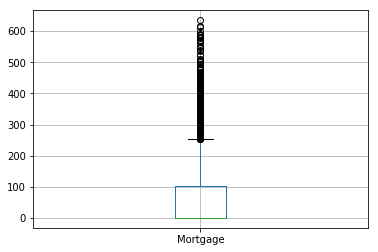

In [273]:
bank.boxplot(column='Mortgage')

In [274]:
print("Standard Deviation of Mortgage Column is : " , np.std(bank["Mortgage"], axis=0))
print("IQR of Mortgage Column is : " , 101.7-0)
print("Range of Mortgage Column is : " , 635-0)
print("Kurtosis of Mortgage Column is : " , kurtosis(bank["Mortgage"]))
print("Skewness of Mortgage Column is : " , skew(bank["Mortgage"]))

Standard Deviation of Mortgage Column is :  101.70363021327891
IQR of Mortgage Column is :  101.7
Range of Mortgage Column is :  635
Kurtosis of Mortgage Column is :  4.75084144430716
Skewness of Mortgage Column is :  2.103371065804789


With the above we understand that :   
1) Mean (5.6) is higher than Median (0).   
2) Box Plot is heavily skewed, showing many outliers.

Since Mortgage is a column which has many values as 0, it simply means that many people have not taken Mortgage at all.   
Had they taken Mortgage it might have been some value usefull for our anaysis.   
So let me convert all the zeros of Mortgage column to Mean of the column.

In [294]:
Mort_Mean = bank.loc[bank['Mortgage']!=0, 'Mortgage'].mean()
Mort_Mean

183.39700130378097

In [299]:
bank['Mortgage'].replace(0,Mort_Mean, inplace=True)

###### Using Variance Inflation Factor method to check the relation between the variables.

In [300]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [301]:
X = bank.drop("Personal Loan", axis=1)
y = bank["Personal Loan"]

In [302]:
X_mat = X.as_matrix()
X_mat.shape

C:\Users\Admin\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


(4984, 13)

In [303]:
vif = [ variance_inflation_factor( X_mat, i ) for i in range( X_mat.shape[1] ) ]

In [304]:
vif_factors = pd.DataFrame()
vif_factors['column'] = list(X.columns)
vif_factors['vif'] = vif
vif_factors

,column,vif
0,ID,4.006557
1,Age,1276.534438
2,Experience,316.723476
3,Income,7.068648
4,ZIP Code,370.735804
5,Family,5.537463
6,CCAvg,3.818115
7,Education,6.685667
8,Mortgage,13.755731
9,Securities Account,1.270811


Since 'Age' vif is greater than 10, removing 'Age' variable from list of features and calculating vif again.

In [305]:
Xcopy = X.copy()

In [306]:
Xcopy = Xcopy.drop('Age', axis=1)

In [307]:
X_mat = Xcopy.as_matrix()
vif = [ variance_inflation_factor( X_mat, i ) for i in range( X_mat.shape[1] ) ]
vif_factors = pd.DataFrame()
vif_factors['column'] = list(Xcopy.columns)
vif_factors['vif'] = vif
vif_factors

C:\Users\Admin\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


,column,vif
0,ID,4.006440
1,Experience,4.104935
2,Income,7.062721
3,ZIP Code,32.553164
4,Family,5.524974
5,CCAvg,3.811739
6,Education,6.246710
7,Mortgage,13.733790
8,Securities Account,1.270176
9,CD Account,1.412113


Since 'ZIP Code' vif is greater than 10, removing 'ZIP Code' variable from list of features and calculating vif again.

In [308]:
Xcopy = Xcopy.drop('ZIP Code', axis=1)

In [309]:
X_mat = Xcopy.as_matrix()
vif = [ variance_inflation_factor( X_mat, i ) for i in range( X_mat.shape[1] ) ]
vif_factors = pd.DataFrame()
vif_factors['column'] = list(Xcopy.columns)
vif_factors['vif'] = vif
vif_factors

C:\Users\Admin\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  """Entry point for launching an IPython kernel.


,column,vif
0,ID,3.637468
1,Experience,3.650057
2,Income,6.907362
3,Family,4.592266
4,CCAvg,3.790413
5,Education,5.095987
6,Mortgage,10.447158
7,Securities Account,1.252454
8,CD Account,1.370355
9,Online,2.431622


In [310]:
X=Xcopy
Xcopy.shape

(4984, 11)

# Here see the pair plot

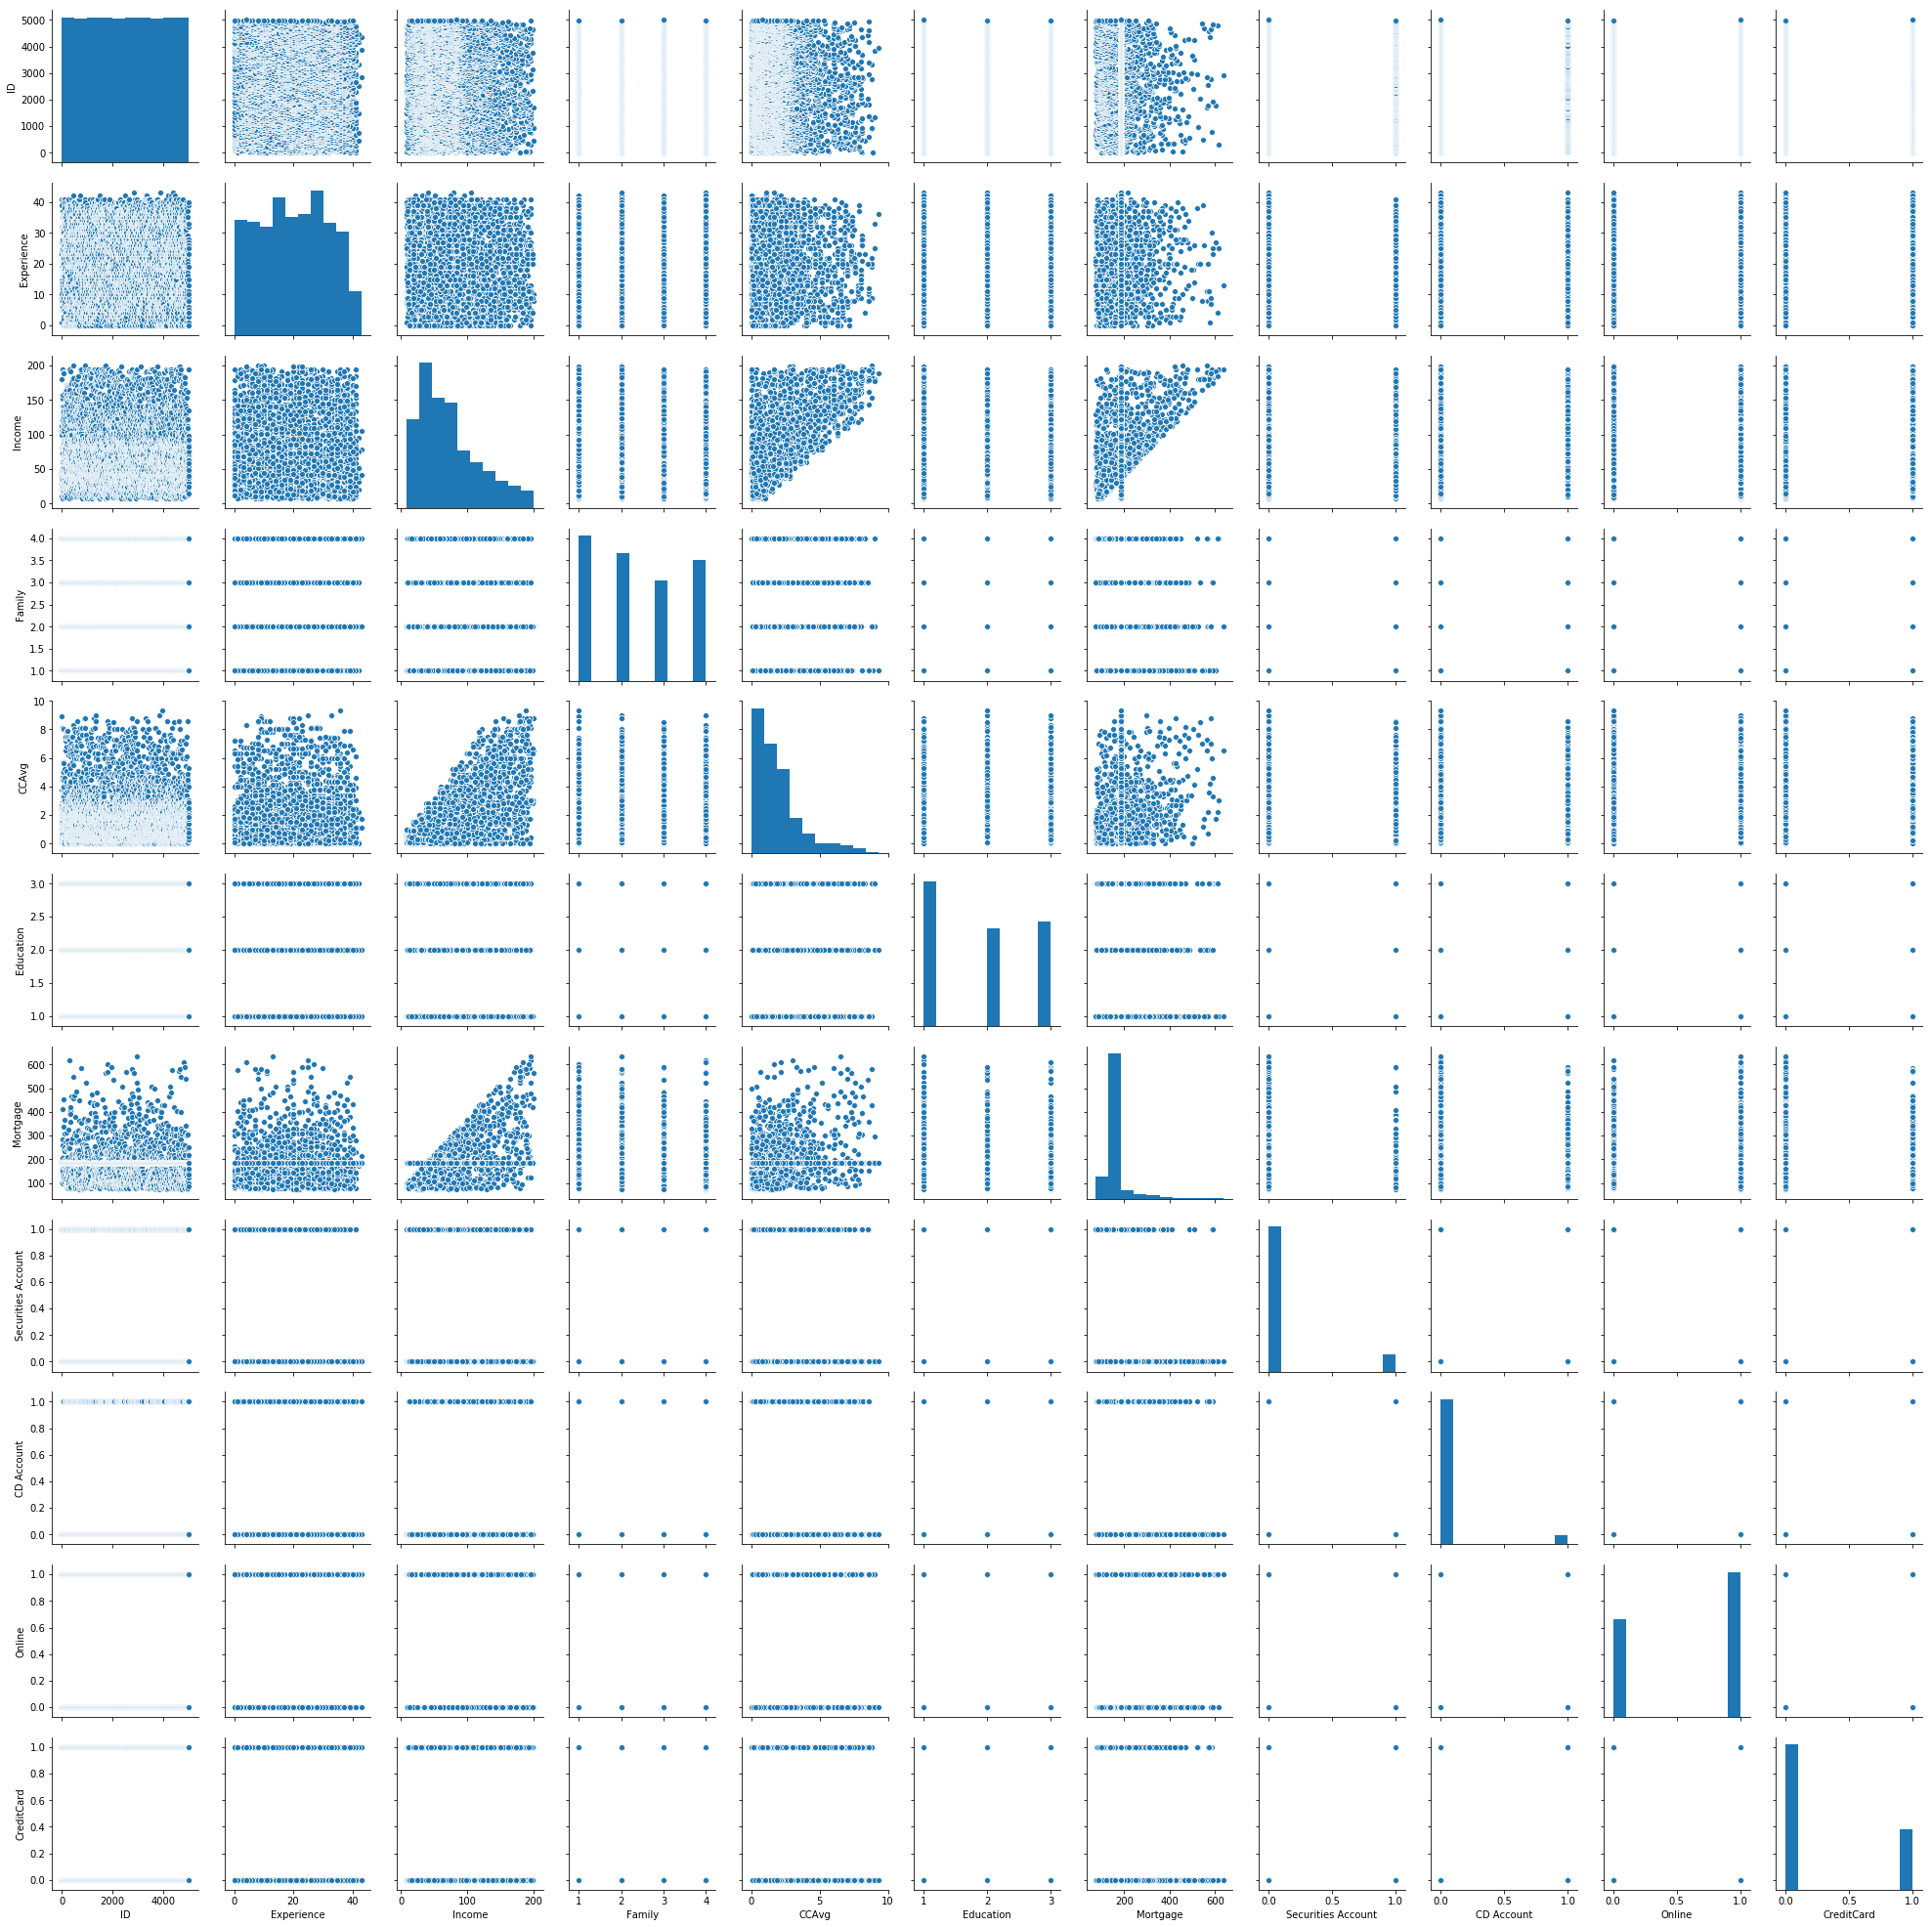

In [346]:
# Pairplot using sns
sns.pairplot(X)

### Q3) Get the target column distribution. Your comments (5 points)

#### Ans)

In [311]:
# Let us look at the target column which is 'class' to understand how the data is distributed amongst the various values
bank.groupby(["Personal Loan"]).count()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
Personal Loan,,,,,,,,,,,,,
0,4507,4507,4507,4507,4507,4507,4507,4507,4507,4507,4507,4507,4507
1,477,477,477,477,477,477,477,477,477,477,477,477,477


#### With this we can infer that with previous campaign process only 9.6% customers took personal loan.

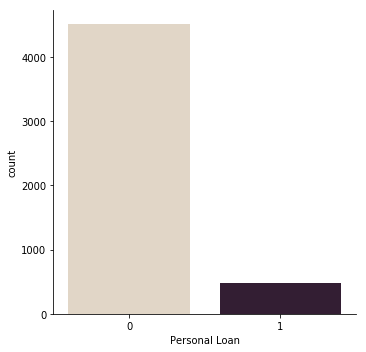

In [312]:
sns.catplot(x="Personal Loan", kind="count", palette="ch:.25", data=bank);

#### With this we can infer that with previous campaign process only 9.6% customers took personal loan.

### Q4) Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)

#### Ans)

In [313]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Q5) Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)

#### Ans)
##### Logistic Regression

In [314]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\Admin\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

In [315]:
# Train accuracy numbers
trainPreds = np.where(model.predict_proba(X_train)[:,1] > 0.5, 1, 0)
trainAccuracy = accuracy_score(y_train, trainPreds)
trainRecall = recall_score(y_train, trainPreds)
trainPrecision = precision_score(y_train, trainPreds)
trainF1score = f1_score(y_train, trainPreds)
trainResults=[X_train.shape[0], 0.5, trainAccuracy, trainRecall, trainPrecision, trainF1score]
   
 # Test accuracy numbers
testPreds = np.where(model.predict_proba(X_test)[:,1] > 0.5, 1, 0)
testAccuracy = accuracy_score(y_test, testPreds)
testRecall = recall_score(y_test, testPreds)
testPrecision = precision_score(y_test, testPreds)
testF1score = f1_score(y_test, testPreds)
testResults=[X_test.shape[0], 0.5, testAccuracy, testRecall, testPrecision, testF1score]

In [316]:
#### Optimize probability threshold and calculate performance numbers
y_predictProb = model.predict_proba(X_train)
fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
optimalF1 = 0
optimalTh = 0
for th in thresholds:
    preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
    f1Score = f1_score(y_train, preds)
    if(optimalF1 < f1Score):
        optimalF1 = f1Score
        optimalTh = th

C:\Users\Admin\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\Admin\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


In [317]:
resultsDf = pd.DataFrame( index=["dataSize", "optimalTh", "accuracy", "recall", "precision", "f1_score"])

# Optimal probability threshold based train accuracy numbers
trainPreds = np.where(model.predict_proba(X_train)[:,1] > optimalTh, 1, 0)
trainAccuracy = accuracy_score(y_train, trainPreds)
trainRecall = recall_score(y_train, trainPreds)
trainPrecision = precision_score(y_train, trainPreds)
trainF1score = f1_score(y_train, trainPreds)
optimalTrainResults=[X_train.shape[0], optimalTh, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    
# Optimal probability threshold based test accuracy numbers
testPreds = np.where(model.predict_proba(X_test)[:,1] > optimalTh, 1, 0)
testAccuracy = accuracy_score(y_test, testPreds)
testRecall = recall_score(y_test, testPreds)
testPrecision = precision_score(y_test, testPreds)
testF1score = f1_score(y_test, testPreds)
optimalTestResults=[X_test.shape[0], optimalTh, testAccuracy, testRecall, testPrecision, testF1score]
    
# Concatenate Train and Test results to resultsDf
resultsDf['unOptimalTrainResults'] = trainResults
resultsDf['unOptimalTestResults'] = testResults
resultsDf['optimalTrainResults'] = optimalTrainResults
resultsDf['optimalTestResults'] = optimalTestResults

In [318]:
resultsDf.round(2)

,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3488.00,1496.00,3488.00,1496.00
optimalTh,0.50,0.50,0.36,0.36
accuracy,0.95,0.95,0.95,0.94
recall,0.57,0.53,0.70,0.64
precision,0.85,0.79,0.75,0.66
f1_score,0.69,0.63,0.72,0.65


##### Naïve Bayes

In [319]:
model1 = GaussianNB()

In [320]:
model1.fit(X_train, y_train)
print(model1)

GaussianNB(priors=None, var_smoothing=1e-09)


In [321]:
# make predictions
predicted = model1.predict(X_test)

In [322]:
model_score = model.score(X_test, y_test)
model_score

0.9451871657754011

In [323]:
y_predictProb = model.predict_proba(X_test)

In [324]:
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])

In [325]:
roc_auc = auc(fpr, tpr)
roc_auc

0.961552370307055

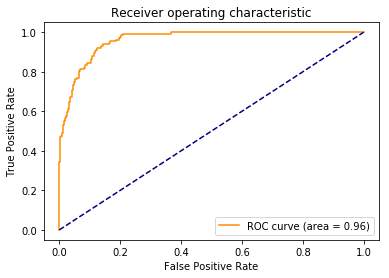

In [326]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [327]:
optimalF1 = 0
optimalTh = 0

In [328]:
THRESHOLD = optimalTh

In [329]:
preds = np.where(model.predict_proba(X_test)[:,1] > THRESHOLD, 1, 0)

In [330]:
pd.DataFrame(data=[accuracy_score(y_test, preds), 
                   recall_score(y_test, preds),
                   precision_score(y_test, preds),
                   f1_score(y_test, preds)], 
             index=["accuracy", "recall", "precision", "f1Score"], columns = {"Score"})

,Score
accuracy,0.089572
recall,1.000000
precision,0.089572
f1Score,0.164417


##### K-NN 

In [331]:
NNH = KNeighborsClassifier(n_neighbors= 21)

In [332]:
# convert the features into z scores as we do not know what units / scales were used and store them in new dataframe
# It is always adviced to scale numeric attributes in models that calculate distances.

X1 = X.apply(zscore)  # convert all attributes to Z scale 

In [333]:
y1 = pd.get_dummies(y, drop_first=True)

In [334]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=test_size, random_state=seed)

In [335]:
# Call Nearest Neighbour algorithm, attaching data making as x and y axis
NNH.fit(X1_train, y1_train)

C:\Users\Admin\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=21, p=2,
           weights='uniform')

In [336]:
# For every test data point, predict it's label based on 5 nearest neighbours in this model. The majority class will 
# be assigned to the test data point
predicted_labels = NNH.predict(X_test)

In [337]:
NNH.score(X1_test, y1_test)

0.9471925133689839

In [338]:
NNH.score(X1_train, y1_train)

0.9501146788990825

In [339]:
pd.DataFrame(data=[accuracy_score(y1_test, predicted_labels), 
                   recall_score(y1_test, predicted_labels),
                   precision_score(y1_test, predicted_labels),
                   f1_score(y1_test, predicted_labels)], 
             index=["accuracy", "recall", "precision", "f1Score"],columns = {"Score"})

,Score
accuracy,0.801471
recall,0.216418
precision,0.131222
f1Score,0.163380


### Q6) Print the confusion matrix for all the above models (10 points)

#### Ans)

Logistic Regression

In [340]:
model_score = model.score(X_test, y_test)
model_score

0.9451871657754011

In [341]:
y_predict = model.predict(X_test)

In [342]:
metrics.confusion_matrix(y_predict, y_test)

array([[1343,   63],
       [  19,   71]], dtype=int64)

### Analyzing the confusion matrix   
True Positives (TP): we correctly predicted that the customer will take loan : 1343

True Negatives (TN): we correctly predicted that the customer will not take loan : 71

False Positives (FP): we incorrectly predicted that the customer will take loan (a "Type I error") 19 Falsely predict positive Type I error

False Negatives (FN): we incorrectly predicted that the customer will not take loan (a "Type II error") 63 Falsely predict negative Type II error

##### K-NN 

In [343]:
metrics.confusion_matrix(y_test, predicted_labels)

array([[1170,  192],
       [ 105,   29]], dtype=int64)

### Analyzing the confusion matrix   
True Positives (TP): we correctly predicted that the customer will take loan : 1170

True Negatives (TN): we correctly predicted that the customer will not take loan : 29

False Positives (FP): we incorrectly predicted that the customer will take loan (a "Type I error") 105 Falsely predict positive Type I error

False Negatives (FN): we incorrectly predicted that the customer will not take loan (a "Type II error") 192 Falsely predict negative Type II error

##### Naïve Bayes

In [344]:
metrics.confusion_matrix(predicted, y_test)

array([[1246,   55],
       [ 116,   79]], dtype=int64)

### Analyzing the confusion matrix   
True Positives (TP): we correctly predicted that the customer will take loan : 1246

True Negatives (TN): we correctly predicted that the customer will not take loan : 79

False Positives (FP): we incorrectly predicted that the customer will take loan (a "Type I error") 116 Falsely predict positive Type I error

False Negatives (FN): we incorrectly predicted that the customer will not take loan (a "Type II error") 55 Falsely predict negative Type II error

### Q7) Give your reasoning on which is the best model in this case and why it performs better? (10 points)

#### Ans)

Since the best f1 score is of Logistic Regression I would consider this model as the best performer.   
Naive Baye's Classifier Model is not expected to give good results as it is used for Document Classification or textual data analysis.    
Also KNN is not expected to perform good because it is build for Legal Analytics.